### Introducción

El **suavizado exponencial** (*Exponential Smoothing*) es una técnica fundamental en el análisis de series de tiempo utilizada para generar pronósticos basados en observaciones pasadas, asignando mayor peso a los datos más recientes. A diferencia de los métodos de promedio móvil, el suavizamiento exponencial incorpora un parámetro de amortiguamiento que controla el grado de respuesta del modelo a los cambios en la tendencia de los datos. Extensiones de este enfoque, como los modelos de **Holt** y **Holt-Winters**, permiten capturar no solo el nivel de la serie, sino también su **tendencia** y **estacionalidad**, lo que los convierte en herramientas muy potentes para el pronóstico de variables que varían con el tiempo, como ventas, demanda energética o métricas financieras.

Para ilustrar el uso de estos modelos, trabajaremos con un **caso de estudio realista**. Imaginemos una empresa llamada *Telco Wave*, un proveedor de servicios de telecomunicaciones que enfrenta un problema recurrente: las **quejas de los clientes** fluctúan semana a semana. Algunas semanas transcurren sin incidentes, mientras que otras son caóticas. Esta variabilidad dificulta que la empresa determine cuántos representantes de atención al cliente necesita en cada periodo. Si asignan demasiados, desperdician recursos; si asignan pocos, los clientes quedan insatisfechos.

Nuestra tarea consiste en **predecir estas oscilaciones** en el número de quejas para ayudar a *Telco Wave* a planificar mejor sus recursos humanos y ofrecer un servicio más eficiente. Antes de aplicar modelos complejos, el primer paso es **comprender los datos**: identificar patrones ocultos, analizar las causas de las fluctuaciones y explorar las características temporales de la serie. Mediante el uso de técnicas de suavizamiento exponencial y modelos de Holt-Winters, podremos traer un poco de orden, permitiendo que la empresa anticipe la demanda de atención, reduzca el número de quejas que pasan desapercibidas y mejore la satisfacción de los clientes, con un impacto directo en la rentabilidad del negocio.


In [1]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_error, mean_absolute_percentage_error

In [2]:
# Importación de datos
df_com = pd.read_csv("data/weekly_customer_complaints.csv")
df_com["week"] = pd.to_datetime(df_com["week"], format="%m/%d/%Y")
df_com.set_index("week", inplace=True)
df_com.head()

,complaints,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,"1,750",37.26%,1,0,0
2018-01-08,"1,701",35.38%,0,0,0
2018-01-15,"1,711",36.22%,1,0,0
2018-01-22,"1,443",38.33%,1,0,0
2018-01-29,"1,397",36.34%,0,0,0


In [3]:
## Vamos a cambiar el nombre de la variable objetivo a "y"
df_com = df_com.rename(columns={"complaints": "y"})
df_com.head()

,y,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,"1,750",37.26%,1,0,0
2018-01-08,"1,701",35.38%,0,0,0
2018-01-15,"1,711",36.22%,1,0,0
2018-01-22,"1,443",38.33%,1,0,0
2018-01-29,"1,397",36.34%,0,0,0


In [4]:
df_com.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 261 entries, 2018-01-01 to 2022-12-26
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   y                        261 non-null    object
 1   discount_rate            261 non-null    object
 2   small_commercial_event   261 non-null    int64 
 3   medium_commercial_event  261 non-null    int64 
 4   big_commercial_event     261 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 12.2+ KB


Tenemos un problema, que la variable objetivo la está tratando como variable object debido a una coma. 

In [5]:
## Removemos la coma y transformamos a un entero
df_com["y"] = df_com["y"].str.replace(",", "").astype(int)
df_com.head()

,y,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,1750,37.26%,1,0,0
2018-01-08,1701,35.38%,0,0,0
2018-01-15,1711,36.22%,1,0,0
2018-01-22,1443,38.33%,1,0,0
2018-01-29,1397,36.34%,0,0,0


## Visualización de datos

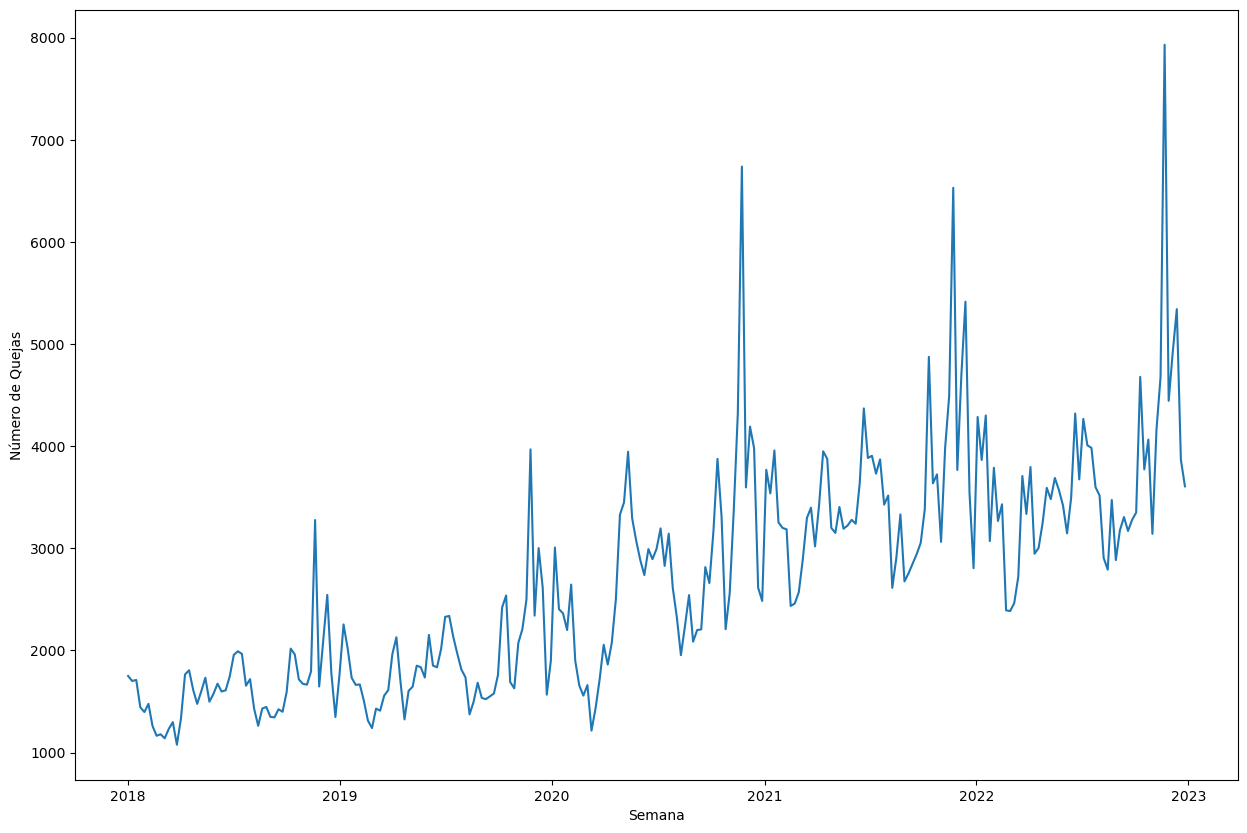

In [6]:
fig = plt.figure(figsize=(15,10))

ax = fig.add_subplot(111)
ax.plot(df_com.index, df_com["y"])
ax.set_xlabel("Semana")
ax.set_ylabel("Número de Quejas")

plt.show()

Podemos ver una tendencia acendente, con picos cada vez más altos.

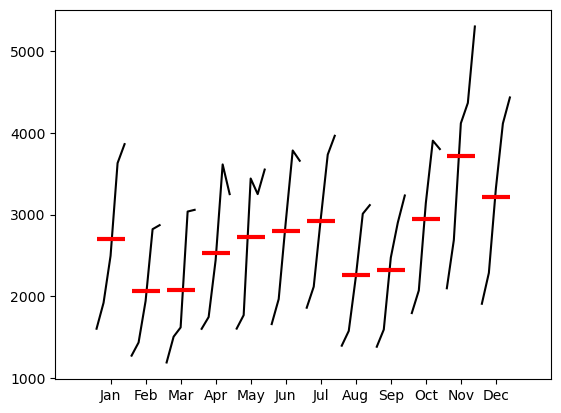

In [7]:
# Vamos a hacer el grafico mensual
month_plot(df_com['y'].resample(rule='ME').mean())
plt.show()

Podemos ver ciertas bajadas y subidas en feb, mar, nov, dec. Parace que el Q4 es el más fuerte en quejas.

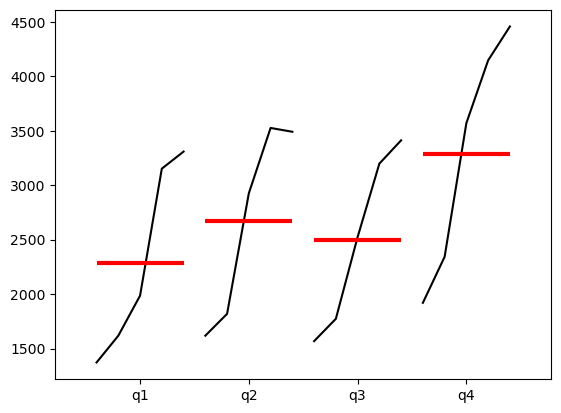

In [8]:
# Quarter plot
quarter_plot(df_com['y'].resample(rule='QE').mean())
plt.show()

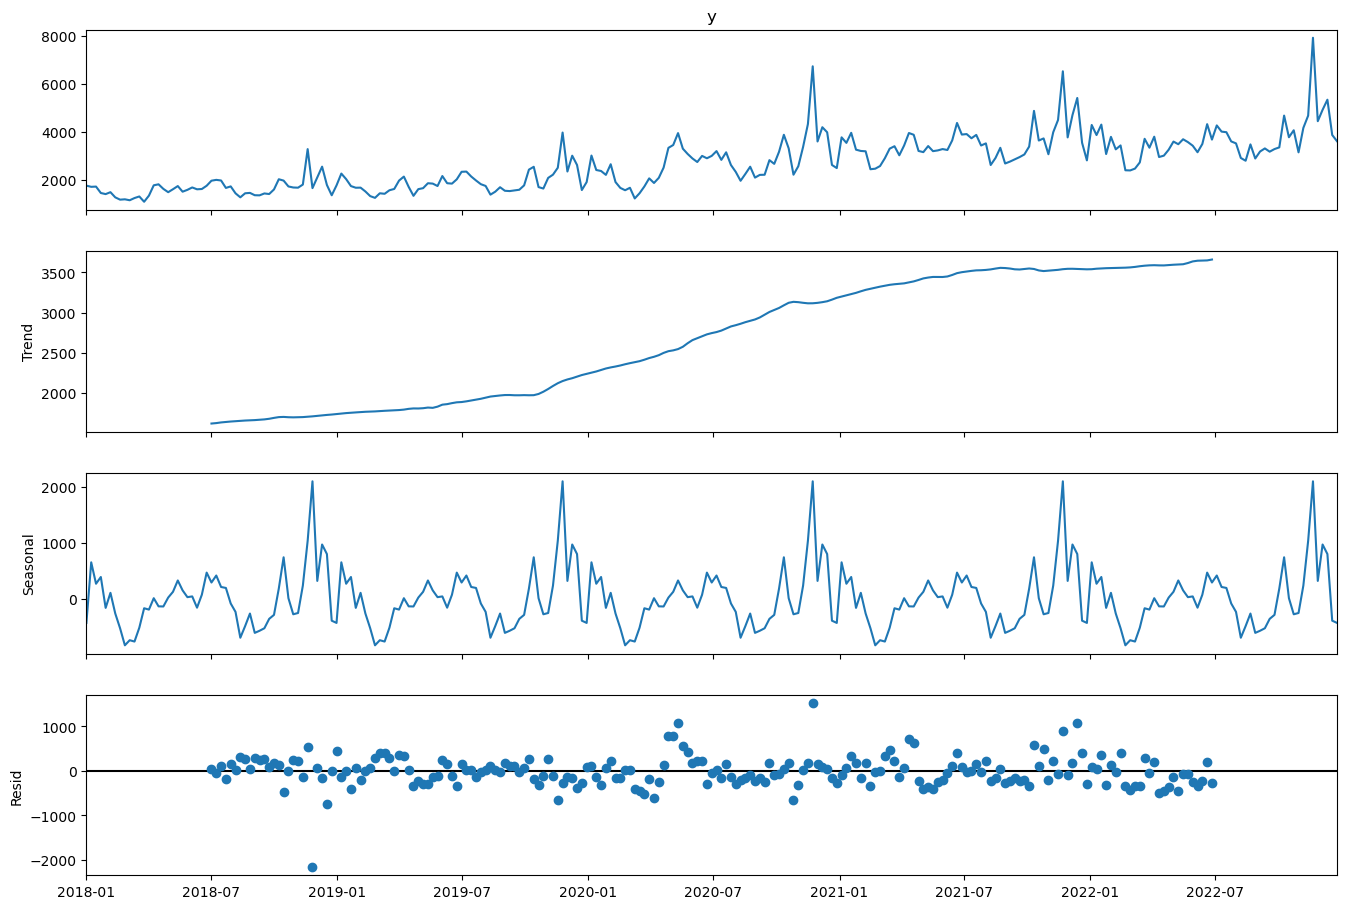

In [9]:
# Descomposición estacional
decomposition = seasonal_decompose(x=df_com['y'],
                                   model='additive',
                                   period=52)
fig = decomposition.plot()
fig.set_size_inches(15,10)
plt.show()

Tenemos los ciclos que no son tan suaves, vemos que estos ciclos le van sumando del orden de 2000 quejas en las temporadas.

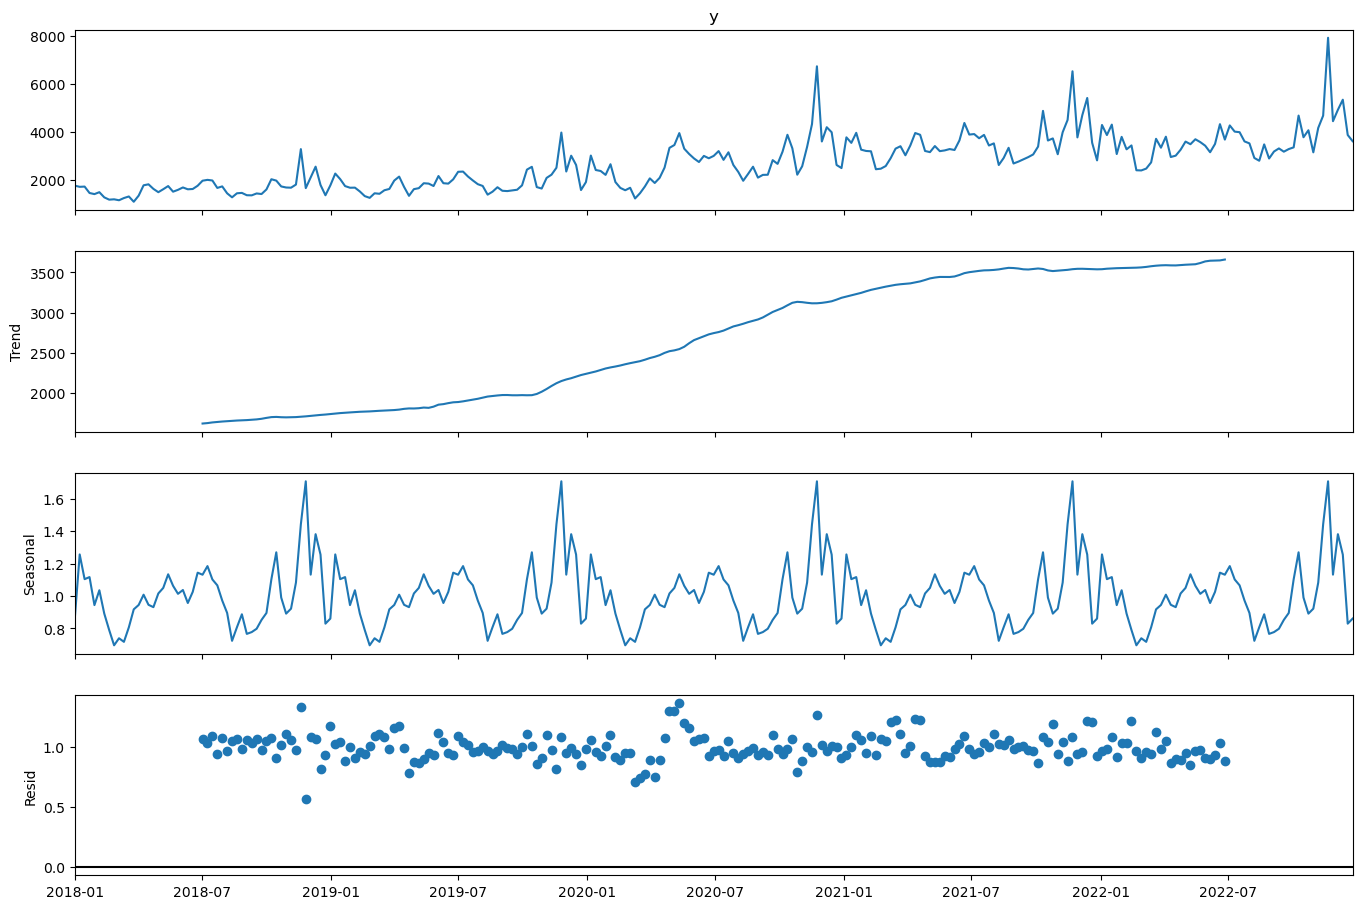

In [10]:
# Descomposición estacional
decomposition = seasonal_decompose(x=df_com['y'],
                                   model='multiplicative',
                                   period=52)
fig = decomposition.plot()
fig.set_size_inches(15,10)
plt.show()

La tendencia se mantiene igual, y aunque la hayamos puesto multiplicativa, como nos indicaban sus picos, no hemos ganado mucha más información.

## Auto correlación y auto correlación parcial

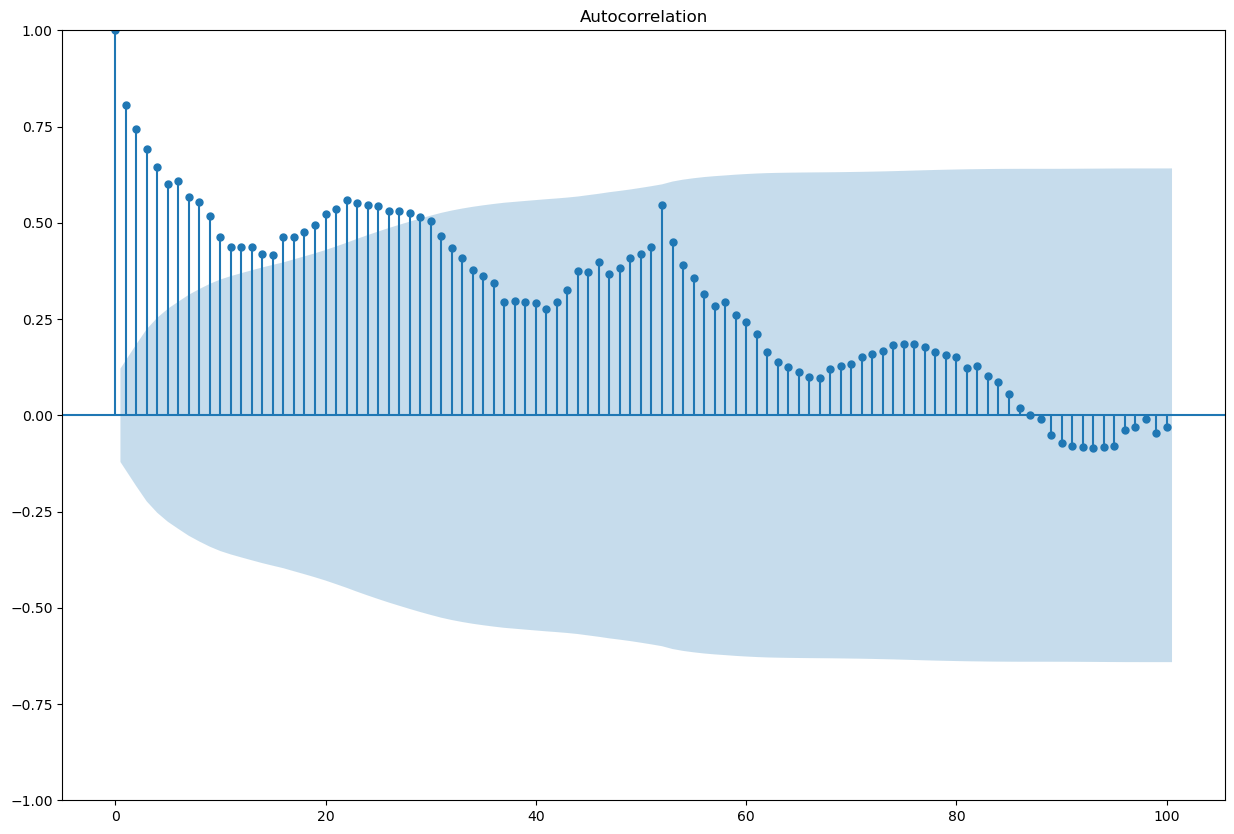

In [11]:
fig, ax = plt.subplots(figsize=(15,10))
plot_acf(df_com['y'], lags=100, ax=ax)
plt.show()

Parece que tenemos algo de información en los últimos 25 periodos.

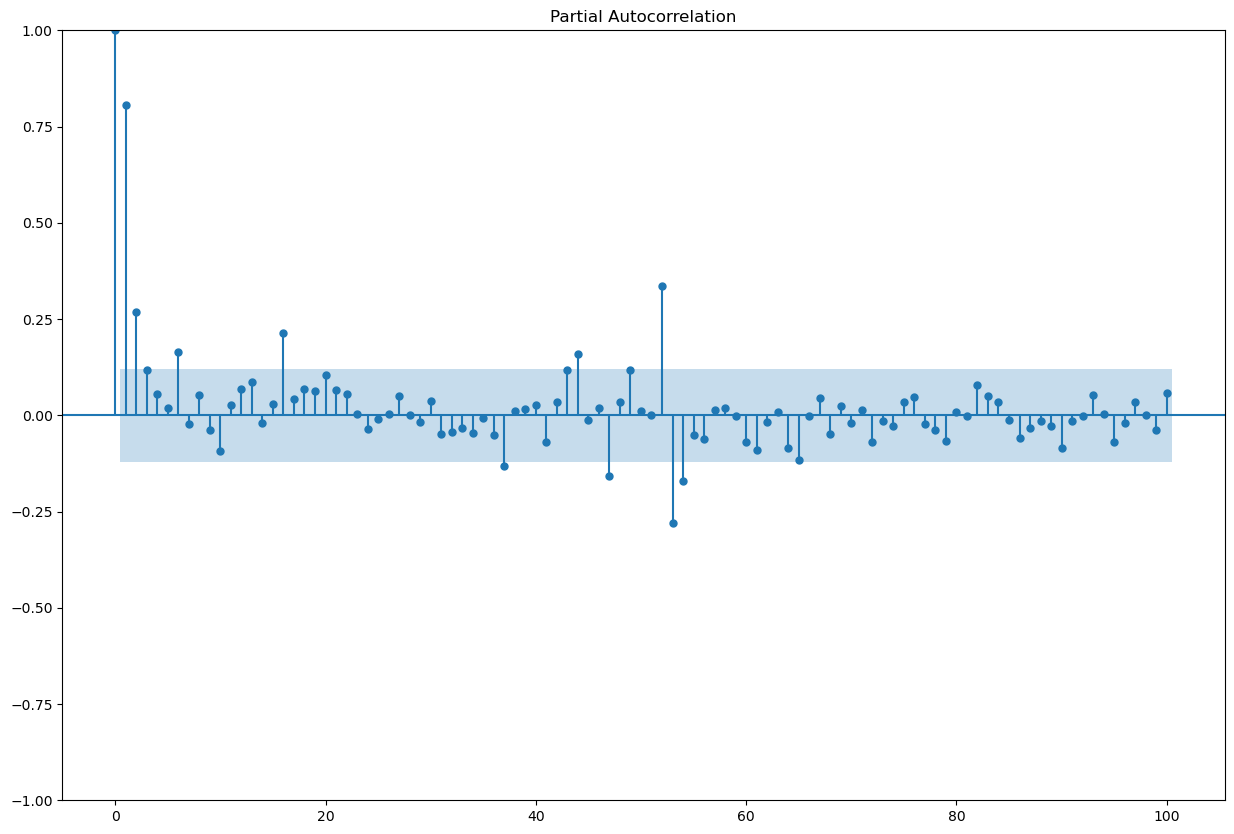

In [12]:
fig, ax = plt.subplots(figsize=(15,10))
plot_pacf(df_com['y'], lags=100, ax=ax)
plt.show()

Tenemos más información de la semana anterior, así como dos semanas antes. También tenemos información en las semanas 6, 16,52,53,54. 
## Frecuencia de la serie de tiempo

In [13]:
# Frecuencia
df_com.index

DatetimeIndex(['2018-01-01', '2018-01-08', '2018-01-15', '2018-01-22',
               '2018-01-29', '2018-02-05', '2018-02-12', '2018-02-19',
               '2018-02-26', '2018-03-05',
               ...
               '2022-10-24', '2022-10-31', '2022-11-07', '2022-11-14',
               '2022-11-21', '2022-11-28', '2022-12-05', '2022-12-12',
               '2022-12-19', '2022-12-26'],
              dtype='datetime64[ns]', name='week', length=261, freq=None)

In [14]:
## Podemos cambiar la frecuencia
# Vemos que los datos son tomados los días lunes
df_com = df_com.asfreq("W-Mon")
df_com.head()

,y,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,1750,37.26%,1,0,0
2018-01-08,1701,35.38%,0,0,0
2018-01-15,1711,36.22%,1,0,0
2018-01-22,1443,38.33%,1,0,0
2018-01-29,1397,36.34%,0,0,0


### División de datos en series de tiempo

Un concepto esencial en el análisis de series de tiempo es la **división del conjunto de datos en entrenamiento y prueba** (*training* y *test set*). Aunque pueda parecer un procedimiento simple, su correcta aplicación es fundamental para obtener modelos de pronóstico confiables y evitar evaluaciones sesgadas.

En un problema de aprendizaje tradicional, normalmente se realiza una **división aleatoria** de los datos, por ejemplo, destinando el 80 % para entrenamiento y el 20 % para prueba. El modelo se entrena con el primer conjunto y se evalúa con el segundo, asegurando así una medición imparcial de su desempeño. Sin embargo, las **series de tiempo** presentan un desafío particular: los datos tienen una **dependencia temporal**, por lo que el orden de las observaciones no puede alterarse. La información de un día o periodo solo cobra sentido en el contexto de los días anteriores y posteriores, y además, el objetivo suele ser **predecir el futuro**.

Por esta razón, al dividir una serie temporal no se realiza una partición aleatoria. En cambio, se **separan los últimos periodos** como conjunto de prueba, manteniendo el orden cronológico. Por ejemplo, si los datos representan semanas, podríamos reservar las últimas cuatro semanas como conjunto de prueba y utilizar las semanas anteriores para entrenamiento. Este enfoque permite evaluar la capacidad del modelo para pronosticar periodos futuros, reproduciendo mejor las condiciones reales de predicción.

El tamaño del conjunto de prueba debe corresponder al **horizonte de pronóstico** deseado: si se busca predecir cuatro semanas, la prueba debe abarcar cuatro semanas; si se pretende pronosticar tres meses, el conjunto de prueba debe incluir tres meses. Además, el conjunto de entrenamiento debe contener **al menos dos ciclos completos** de los datos (por ejemplo, dos o tres años en datos semanales) para garantizar que el modelo pueda aprender patrones estacionales y tendencias de manera robusta. De esta forma, se obtiene una base sólida para construir modelos de pronóstico precisos y generalizables.


In [15]:
# Datos de entrenamieno y prueba
# El objetivo será predecir las siguientes 13 semanas
# Solo usamos la variable y

periods = 13
df_train = df_com[:-periods].y.to_frame()
df_test = df_com[-periods:].y.to_frame()

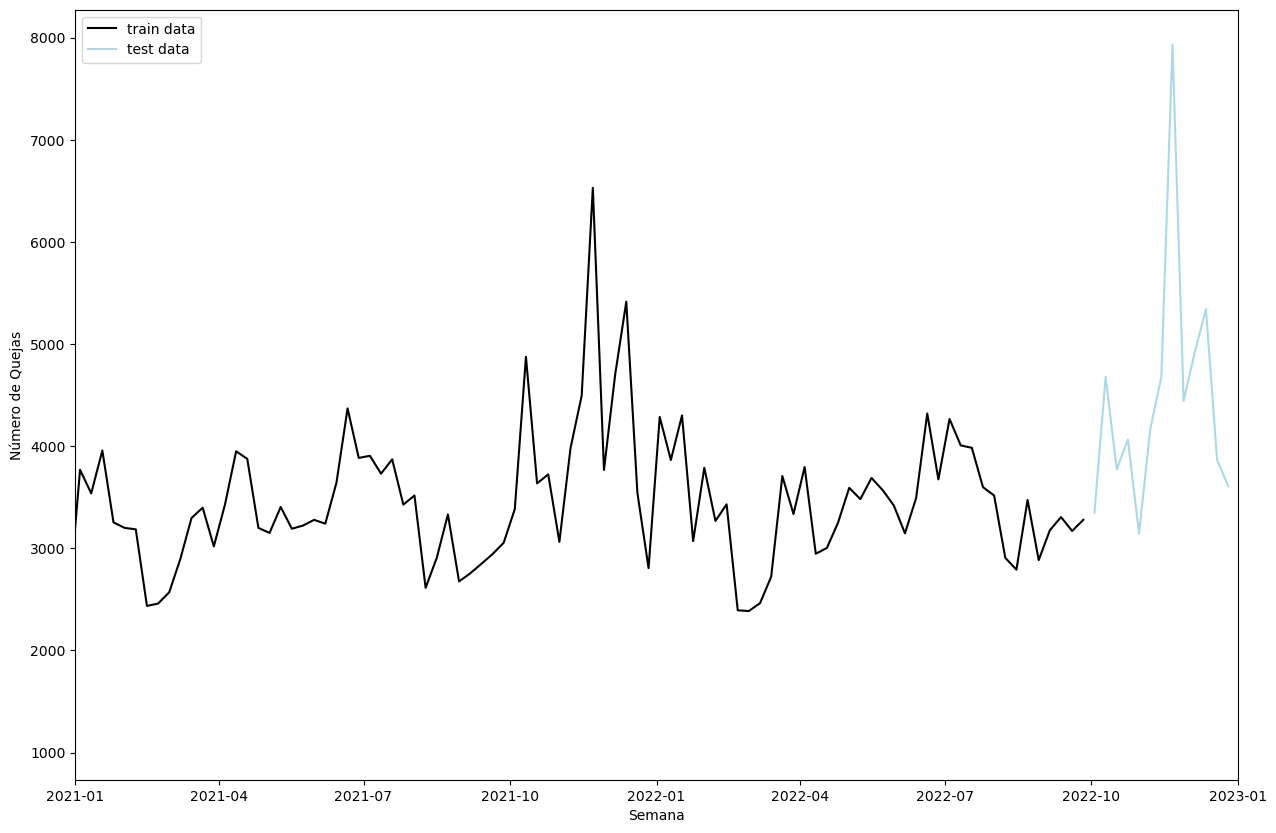

In [16]:
fig = plt.figure(figsize=(15,10))

ax = fig.add_subplot(111)
ax.plot(df_train.index, df_train["y"], color='black', label='train data')
ax.plot(df_test.index, df_test["y"], color='lightblue', label='test data')
ax.set_xlabel("Semana")
ax.set_ylabel("Número de Quejas")
ax.set_xlim("2021","2023")
ax.legend()

plt.show()

In [17]:
# Otra forma de hacer esta división de datos
periods = 13
df_train, df_test = df_com.iloc[:-periods,0].to_frame(), df_com.iloc[-periods:,0].to_frame()

## Suavizado Exponencial Simple

El **suavizado exponencial simple** (*Simple Exponential Smoothing*, SES) es uno de los métodos más básicos y útiles en pronóstico de series de tiempo. Su objetivo es encontrar un **ritmo estable** dentro de una secuencia de observaciones que presentan fluctuaciones —por ejemplo, las ventas o las quejas semanales de una empresa—, atenuando las variaciones abruptas para revelar la tendencia subyacente.  

A diferencia de un promedio móvil, este método **asigna mayor peso a las observaciones más recientes**, bajo la premisa de que los datos recientes contienen más información sobre el futuro que los valores antiguos. Matemáticamente, el suavizamiento exponencial simple se define mediante la siguiente ecuación recursiva:

\begin{equation}
\hat{y}_{t+1} = \alpha y_t + (1 - \alpha)\hat{y}_t
\end{equation}

donde:  

- $\hat{y}_{t+1}$ es el **pronóstico para el siguiente periodo**,  
- $y_t$ es el **valor observado en el periodo actual**,  
- $\hat{y}_t$ es el **nivel suavizado** o pronóstico previo,  
- $\alpha$ es el **parámetro de suavizamiento**, con \( 0 < \alpha < 1 \).  

Otra forma equivalente de expresar la ecuación, que resalta el papel del ajuste incremental, es:

\begin{equation}
\hat{y}_{t+1} = \hat{y}_t + \alpha (y_t - \hat{y}_t)
\end{equation}

Aquí, $(y_t - \hat{y}_t)$ representa la **diferencia entre el valor observado y el nivel actual** (el “error”), y $\alpha$ controla cuánto se ajusta el nivel hacia ese nuevo valor.  

**Interpretación del parámetro $\alpha$:**  
- Si $\alpha$ se acerca a **1**, el modelo responde rápidamente a los cambios recientes, dando más peso a las últimas observaciones.  
- Si $\alpha$ se acerca a **0**, el modelo reacciona lentamente, conservando más influencia del pasado.  

**Ejemplo:**  
Supongamos que el nivel actual $( \hat{y}_t $) es 100 tazas vendidas, el valor observado $( y_t )$ fue 120, y $ \alpha = 0.2 $. Entonces:

\begin{equation}
\hat{y}_{t+1} = 100 + 0.2(120 - 100) = 104
\end{equation}

Esto significa que el modelo ajusta su pronóstico ligeramente hacia arriba, reconociendo el aumento reciente, pero sin reaccionar de manera exagerada a un posible pico aislado.  

El suavizamiento exponencial simple es particularmente útil para **series sin tendencia ni estacionalidad**, cuando se busca reducir la variabilidad y obtener una visión más clara de la dirección general de los datos. Sin embargo, debido a su simplicidad, **no captura tendencias crecientes ni patrones estacionales**; para ello se emplean extensiones como los modelos de **Holt** y **Holt-Winters**, que amplían esta lógica básica incorporando componentes de tendencia y estacionalidad.  


In [18]:
# Suavizado exponencial simple
# SES (datos de entrenamiento)

ses_model = SimpleExpSmoothing(df_train).fit()
ses_model.summary()

Dep. Variable:,y,No. Observations:,248
Model:,SimpleExpSmoothing,SSE,74355478.081
Optimized:,True,AIC,3131.513
Trend:,None,BIC,3138.540
Seasonal:,None,AICC,3131.678
Seasonal Periods:,None,Date:,"Wed, 29 Oct 2025"
Box-Cox:,False,Time:,23:58:47
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.5097818,alpha,True
initial_level,1750.0000,l.0,False


El nivel inicial es el primer valor en la serie de tiempo, pero esto cambia con el tiempo. Luego tenemos el nivel de suavizado.

#### Información general del modelo

| Campo | Significado |
|:------|:-------------|
| **Dep. Variable: y** | Variable dependiente del modelo, es decir, la serie temporal que se está pronosticando (por ejemplo, ventas o quejas semanales). |
| **No. Observations: 248** | Número total de observaciones utilizadas para entrenar el modelo. |
| **Model: SimpleExpSmoothing** | Indica que se usó el modelo de **suavizamiento exponencial simple**, sin componentes de tendencia ni estacionalidad. |
| **Optimized: True** | El parámetro de suavizamiento $\alpha$ fue optimizado automáticamente para minimizar el error cuadrático. |
| **Trend / Seasonal / Seasonal Periods: None** | Confirma que el modelo no incluye tendencia ni estacionalidad, lo cual es propio del suavizamiento exponencial simple. |

#### Parámetros estimados

| Parámetro | Nombre en el modelo | Valor | Interpretación |
|:-----------|:-------------------|:-------|:----------------|
| **smoothing_level** | $\alpha$ | **0.5097818** | Es el parámetro de suavizamiento. Un valor cercano a **0.5** indica que el modelo da un **peso equilibrado** entre las observaciones recientes y las pasadas. Valores más altos (≈1) hacen que el modelo reaccione rápidamente a los cambios; valores más bajos (≈0) producen un comportamiento más estable y lento para adaptarse. |
| **initial_level (l.0)** | $ \ell_0 $ | **1750.0000** | Es el **nivel inicial** o punto de partida del modelo. En este caso, se fijó manualmente y no fue optimizado. Representa el valor base a partir del cual se generan los pronósticos. |

In [19]:
# Predicciones
periods=13
ses_pred = ses_model.forecast(periods)
ses_pred.to_frame()

,0
2022-10-03,3236.663471
2022-10-10,3236.663471
2022-10-17,3236.663471
2022-10-24,3236.663471
2022-10-31,3236.663471
2022-11-07,3236.663471
2022-11-14,3236.663471
2022-11-21,3236.663471
2022-11-28,3236.663471
2022-12-05,3236.663471


In [20]:
# Calcular con el nivel inicial
df_train.iloc[-1]*0.51 + 1750

y    3422.29
Name: 2022-09-26 00:00:00, dtype: float64

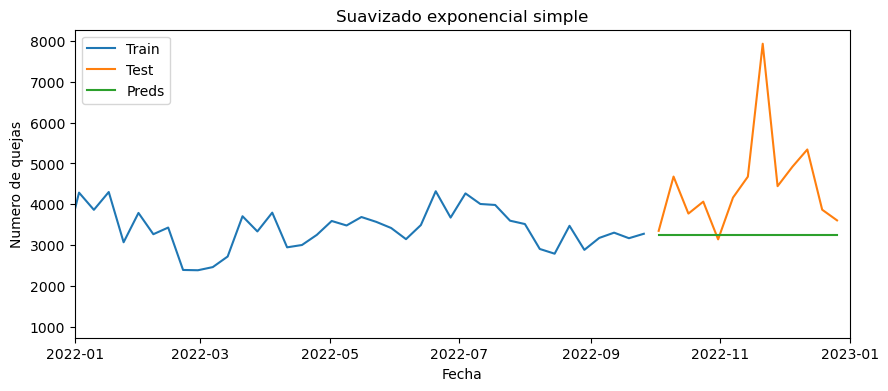

In [21]:
# Visualización
plt.figure(figsize=(10,4))

# Graficar datos de entrenamiento y validacion, y predicciones
plt.plot(df_train, label="Train")
plt.plot(df_test, label="Test")
plt.plot(ses_pred, label="Preds")
plt.xlabel("Fecha")
plt.ylabel("Numero de quejas")
plt.title("Suavizado exponencial simple")
plt.xlim("2022", "2023")
plt.legend()
plt.show()

### Suavizado Exponencial Doble (Método de Holt)

El **suavizado exponencial doble**, también conocido como **método de Holt**, es una extensión natural del suavizado exponencial simple. Mientras que el modelo simple se enfoca únicamente en **suavizar los niveles** de una serie temporal (reduciendo el ruido y las fluctuaciones puntuales), el modelo doble introduce un segundo componente para capturar la **tendencia** subyacente de los datos a lo largo del tiempo.

En otras palabras, además de ajustar el nivel general de la serie, este método también aprende si los valores están **aumentando o disminuyendo de forma sostenida**. Esto lo hace especialmente útil cuando los datos presentan una dirección clara (por ejemplo, ventas o quejas que crecen o decrecen semana a semana).

---

#### Estructura del modelo

El suavizamiento exponencial doble se basa en **dos ecuaciones recursivas**: una para el **nivel** y otra para la **tendencia**.

\begin{equation}
\begin{aligned}
\text{Nivel: } & \ell_t = \alpha y_t + (1 - \alpha)(\ell_{t-1} + b_{t-1}) \\
\text{Tendencia: } & b_t = \beta (\ell_t - \ell_{t-1}) + (1 - \beta)b_{t-1} \\
\text{Pronóstico: } & \hat{y}_{t+h} = \ell_t + h b_t
\end{aligned}
\end{equation}

donde:

- $y_t$: valor observado en el tiempo $t$  
- $\ell_t$: nivel suavizado en el tiempo $t$  
- $b_t$: tendencia suavizada (pendiente estimada)  
- $\alpha$: parámetro de suavizamiento del nivel, $0 < \alpha < 1$
- $\beta$: parámetro de suavizamiento de la tendencia, $0 < \beta < 1$
- $\hat{y}_{t+h}$: pronóstico para $h$ pasos hacia adelante  

---

#### Interpretación de los parámetros

| Parámetro | Significado | Interpretación |
|:-----------|:-------------|:---------------|
| $\alpha$ | Suavizado del nivel | Controla cuánto se ajusta el nivel a los nuevos datos. Valores altos hacen que el modelo reaccione más rápido a los cambios recientes. |
| $\beta$ | Suavizado de la tendencia | Ajusta la velocidad de respuesta del componente de tendencia. Valores altos hacen que la tendencia se actualice rápidamente ante cambios recientes. |

#### Ejemplo conceptual

Supongamos que las ventas semanales de una empresa están aumentando con fluctuaciones.  
El modelo de suavizamiento exponencial simple podría captar el nivel promedio, pero **no reflejaría el crecimiento sostenido**.  
En cambio, el modelo doble ajusta tanto el nivel como la tendencia, permitiendo generar pronósticos que **siguen la dirección general de los datos**.

Por ejemplo, si las ventas aumentan cada semana en promedio, el término $b_t$ (la tendencia) será positivo, incrementando gradualmente el pronóstico futuro:

\begin{equation}
\hat{y}_{t+1} = \ell_t + b_t
\end{equation}

---

#### Limitaciones

Aunque el suavizado exponencial doble **maneja correctamente tendencias lineales**, aún **no captura patrones estacionales** (por ejemplo, fluctuaciones regulares por meses o estaciones del año). Para abordar ese tipo de comportamiento periódico, se requiere una extensión adicional: el **suavizado exponencial triple**, o modelo de **Holt-Winters**, que incluye un tercer componente para la estacionalidad.

In [22]:
# Suavizado exponencial doble
model_double = ExponentialSmoothing(endog=df_train,
                                   trend="additive", # lineal
                                   seasonal=None, # reservado a triple suavizado exponencial
                                   ).fit()
model_double.summary()

Dep. Variable:,y,No. Observations:,248
Model:,ExponentialSmoothing,SSE,74343958.274
Optimized:,True,AIC,3135.474
Trend:,Additive,BIC,3149.528
Seasonal:,None,AICC,3135.823
Seasonal Periods:,None,Date:,"Wed, 29 Oct 2025"
Box-Cox:,False,Time:,23:58:50
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.5093865,alpha,True
smoothing_trend,0.000000,beta,True


In [23]:
# Predicciones
periods=13
model_double_pred = model_double.forecast(periods)
model_double_pred.to_frame()

,0
2022-10-03,3248.187568
2022-10-10,3254.077685
2022-10-17,3259.967801
2022-10-24,3265.857918
2022-10-31,3271.748034
2022-11-07,3277.638150
2022-11-14,3283.528267
2022-11-21,3289.418383
2022-11-28,3295.308500
2022-12-05,3301.198616


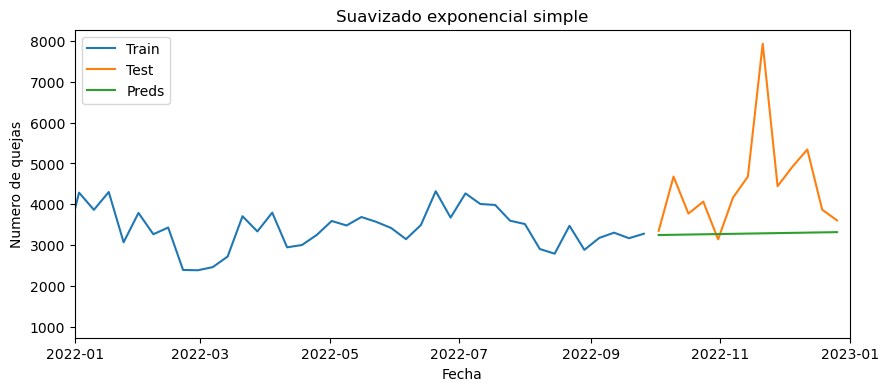

In [24]:
# Visualización
plt.figure(figsize=(10,4))

# Graficar datos de entrenamiento y validacion, y predicciones
plt.plot(df_train, label="Train")
plt.plot(df_test, label="Test")
plt.plot(model_double_pred, label="Preds")
plt.xlabel("Fecha")
plt.ylabel("Numero de quejas")
plt.title("Suavizado exponencial simple")
plt.xlim("2022", "2023")
plt.legend()
plt.show()

### Suavizado Exponencial Triple (Método de Holt-Winters)

El **suavizado exponencial triple**, también conocido como el **método de Holt-Winters**, es una extensión del suavizado simple y doble que permite modelar **series de tiempo con tendencia y estacionalidad**. Mientras que el método de Holt (doble suavizamiento) capta la tendencia, Holt-Winters añade un tercer componente que captura los **patrones cíclicos o repetitivos** presentes en los datos, como los cambios estacionales o las fluctuaciones regulares a lo largo del tiempo.

---

#### Componentes del modelo

El modelo divide la serie temporal en **tres componentes principales**:

1. **Nivel $( \ell_t )$**: representa el valor base o promedio general de la serie en el tiempo.  
2. **Tendencia $( b_t )$**: captura la dirección general de los datos, es decir, si aumentan o disminuyen con el tiempo.  
3. **Estacionalidad $( s_t )$**: refleja los patrones que se repiten en intervalos regulares, como picos mensuales, semanales o anuales.

Así, el suavizamiento exponencial triple se puede expresar mediante tres ecuaciones recursivas, una para cada componente:

\begin{equation}
\begin{aligned}
\text{Nivel: } & \ell_t = \alpha \frac{y_t}{s_{t-m}} + (1 - \alpha)(\ell_{t-1} + b_{t-1}) \\
\text{Tendencia: } & b_t = \beta (\ell_t - \ell_{t-1}) + (1 - \beta)b_{t-1} \\
\text{Estacionalidad: } & s_t = \gamma \frac{y_t}{\ell_t} + (1 - \gamma)s_{t-m} \\
\text{Pronóstico: } & \hat{y}_{t+h} = (\ell_t + hb_t) s_{t-m+h}
\end{aligned}
\end{equation}

donde:

- $y_t$: valor observado en el tiempo $t$  
- $\ell_t$: nivel suavizado  
- $b_t$: tendencia suavizada  
- $s_t$: componente estacional  
- $m$: número de periodos por ciclo estacional (por ejemplo, 12 para datos mensuales con estacionalidad anual)  
- $\alpha, \beta, \gamma$: parámetros de suavizamiento (nivel, tendencia y estacionalidad)  

---

#### Interpretación de los parámetros

| Parámetro | Controla | Interpretación |
|:-----------|:----------|:---------------|
| $\alpha$ | Nivel | Cuánto peso se da a los datos recientes en la actualización del nivel. |
| $\beta$ | Tendencia | Cuánto se ajusta la tendencia ante los cambios recientes. |
| $\gamma$ | Estacionalidad | Qué tanto se actualiza el patrón estacional en función de las nuevas observaciones. |

El suavizamiento exponencial triple amplía las capacidades del modelo exponencial al incorporar un componente estacional proporcionando así una herramienta robusta para el pronóstico de series de tiempo complejas. Cuando el análisis exploratorio de datos (**EDA**) revela **curvas estacionales pronunciadas**, el uso de Holt-Winters es esencial, ya que modelos más simples —como el suavizado simple o doble— no pueden capturar adecuadamente esos patrones repetitivos.


In [25]:
## Holt Winter (Suavizado exponencial triple)
model_holt = ExponentialSmoothing(
    endog=df_train,
    trend="add",
    seasonal="mul",
    seasonal_periods=52
).fit()
display(model_holt.summary())

Dep. Variable:,y,No. Observations:,248
Model:,ExponentialSmoothing,SSE,21600694.682
Optimized:,True,AIC,2932.952
Trend:,Additive,BIC,3129.704
Seasonal:,Multiplicative,AICC,2969.164
Seasonal Periods:,52,Date:,"Wed, 29 Oct 2025"
Box-Cox:,False,Time:,23:58:51
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.2491251,alpha,True
smoothing_trend,0.000000,beta,True


In [26]:
# Predicciones
periods=13
model_triple_pred = model_holt.forecast(periods)
model_triple_pred.to_frame()

,0
2022-10-03,4041.214307
2022-10-10,5040.731845
2022-10-17,3932.016356
2022-10-24,3531.277968
2022-10-31,3441.236893
2022-11-07,4260.272593
2022-11-14,5352.830818
2022-11-21,7238.316837
2022-11-28,4359.178099
2022-12-05,5316.708617


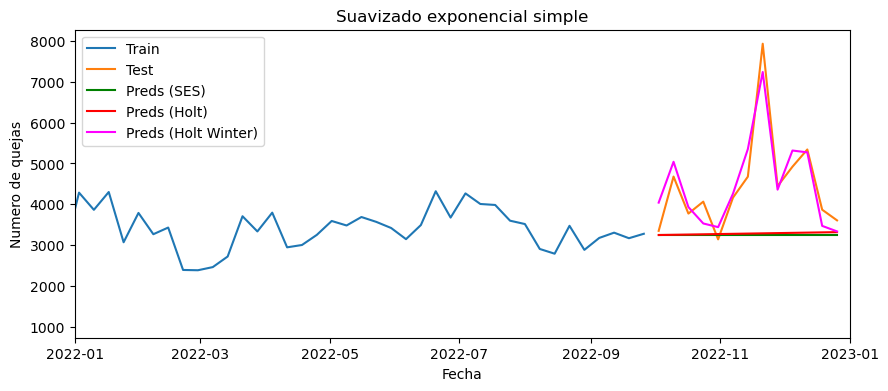

In [27]:
# Visualización
plt.figure(figsize=(10,4))

# Graficar datos de entrenamiento y validacion, y predicciones
plt.plot(df_train, label="Train")
plt.plot(df_test, label="Test")
plt.plot(ses_pred, label="Preds (SES)", color="green")
plt.plot(model_double_pred, label="Preds (Holt)", color="red")
plt.plot(model_triple_pred, label="Preds (Holt Winter)", color="magenta")
plt.xlabel("Fecha")
plt.ylabel("Numero de quejas")
plt.title("Suavizado exponencial simple")
plt.xlim("2022", "2023")
plt.legend()
plt.show()

In [28]:
# Calculamos el RMSE, MAE y MAPE
rmse = root_mean_squared_error(df_test, model_triple_pred)
mae = mean_absolute_error(df_test, model_triple_pred)
mape = mean_absolute_percentage_error(df_test, model_triple_pred)

print(f"RMSE: {rmse:.0f}")
print(f"MAE: {mae:.0f}")
print(f"MAPE: {100*mape:.1f} %")

RMSE: 425
MAE: 364
MAPE: 8.4 %


## Predecir el futuro

In [30]:
# Exploramos los datos
df_com.head()

,y,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,1750,37.26%,1,0,0
2018-01-08,1701,35.38%,0,0,0
2018-01-15,1711,36.22%,1,0,0
2018-01-22,1443,38.33%,1,0,0
2018-01-29,1397,36.34%,0,0,0


In [32]:
# Construimos un modelo Winter Holt con todos los datos

model_holt_complete = ExponentialSmoothing(
    endog=df_com.y,
    trend="add",
    seasonal="mul",
    seasonal_periods=52
).fit()

In [33]:
# Predecimos el futuro 
forecast = model_holt_complete.forecast(13)
forecast[:5]

2023-01-02    4965.806183
2023-01-09    4478.060886
2023-01-16    4699.482938
2023-01-23    3814.090177
2023-01-30    4241.989889
Freq: W-MON, dtype: float64

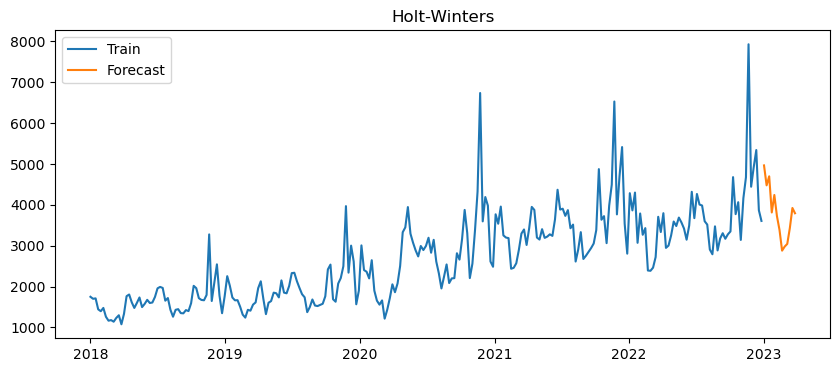

In [34]:
# Grafico para datos de entrenamiento y forecast
plt.figure(figsize=(10,4))

# Grafico entrenamiento, test y forecast
plt.plot(df_com.y, label="Train")
plt.plot(forecast, label="Forecast")

plt.title("Holt-Winters")
plt.legend()
plt.show()

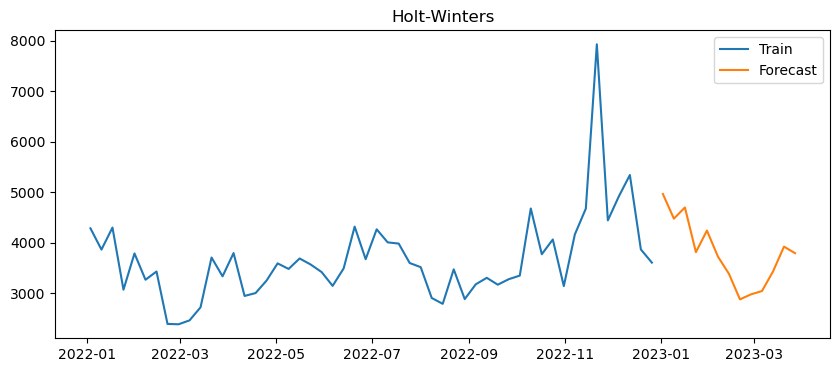

In [38]:
def plot_future(y,forecast,chart_title=None):
    # Grafico para datos de entrenamiento y forecast
    plt.figure(figsize=(10,4))
    
    # Grafico entrenamiento, test y forecast
    plt.plot(y, label="Train")
    plt.plot(forecast, label="Forecast")
    
    plt.title("Holt-Winters")
    plt.legend()
    plt.show()

plot_future(df_com["y"].loc["2022"],forecast,"Holt-Winters")

## Datos diarios (BTC)

In [43]:
df_btc = pd.read_csv("data/bitcoin_price_2015_2025.csv", index_col="Date", parse_dates=True, usecols=["Date", "Close"])
df_btc.head()

,Close
Date,
2015-01-01,314.248993
2015-01-02,315.032013
2015-01-03,281.082001
2015-01-04,264.195007
2015-01-05,274.473999


In [44]:
# Ponerlo en frecuencia diaria
df_btc_daily = df_btc.asfreq('D')
df_btc_daily.index

DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04',
               '2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09', '2015-01-10',
               ...
               '2025-09-07', '2025-09-08', '2025-09-09', '2025-09-10',
               '2025-09-11', '2025-09-12', '2025-09-13', '2025-09-14',
               '2025-09-15', '2025-09-16'],
              dtype='datetime64[ns]', name='Date', length=3912, freq='D')

## Modelado

Vamos a predecir datos a 30 días

In [46]:
periods = 30
train, test = df_btc_daily.iloc[:-periods,0], df_btc_daily.iloc[-periods:,0]

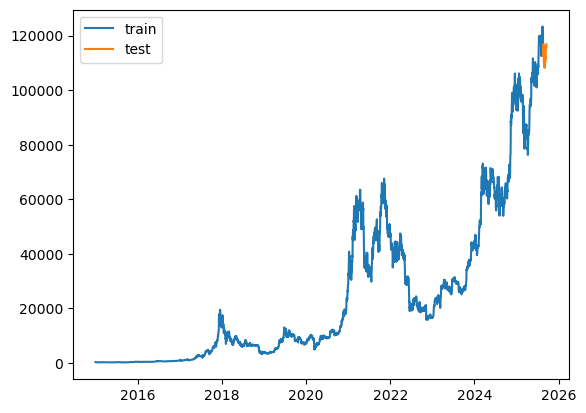

In [52]:
# plot
plt.plot(train.index, train, label="train")
plt.plot(test.index, test, label="test")
plt.legend()
plt.show()

In [63]:
model_daily = ExponentialSmoothing(
    endog=train,
    trend = "mul",
    seasonal="mul",
    seasonal_periods=365
).fit()

/opt/homebrew/Caskroom/miniconda/base/envs/ds_env/lib/python3.10/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


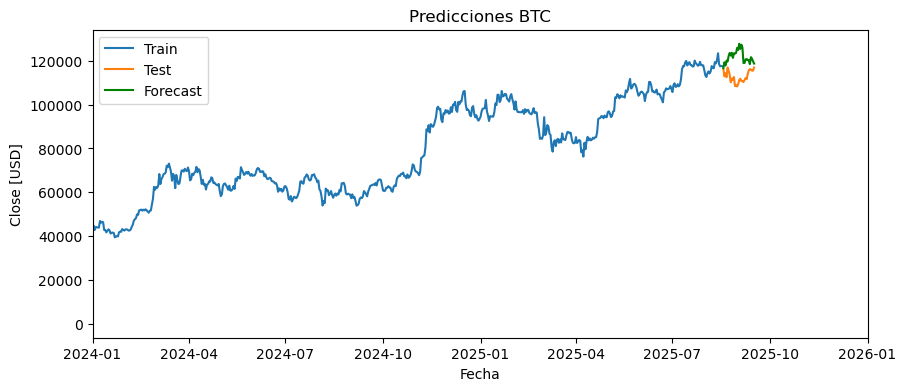

RMSE: 10258
MAE: 9030
MAPE: 8.1 %


In [64]:
# predecir
daily_pred = model_daily.forecast(periods)

# Visualización
plt.figure(figsize=(10,4))

# Graficar datos de entrenamiento y validacion, y predicciones
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(daily_pred, label="Forecast", color="green")
plt.xlabel("Fecha")
plt.ylabel("Close [USD]")
plt.title("Predicciones BTC")
plt.xlim("2024", "2026")
plt.legend()
plt.show()

# Calculamos el RMSE, MAE y MAPE
rmse = root_mean_squared_error(test, daily_pred)
mae = mean_absolute_error(test, daily_pred)
mape = mean_absolute_percentage_error(test, daily_pred)

print(f"RMSE: {rmse:.0f}")
print(f"MAE: {mae:.0f}")
print(f"MAPE: {100*mape:.1f} %")

## Ventajas y desventajas del método Holt-Winters

**1. Sencillez y facilidad de implementación**

El método Holt-Winters es uno de los favoritos en el mundo de la predicción de series de tiempo, especialmente cuando se trata de problemas **no demasiado complejos con tendencia y estacionalidad**. Su principal ventaja es su **implementación simple y directa**: no se requiere un conocimiento matemático avanzado para ponerlo en marcha, lo que lo hace accesible para muchos usuarios.

**2. Intuición del modelo**

El modelo se basa en tres componentes fáciles de entender:
- El **nivel** actual de la serie ($L_t$),
- La **tendencia** ($B_t$),
- Y la **estacionalidad** ($S_t$).

Estos elementos permiten que su lógica sea bastante intuitiva. Los parámetros de suavizamiento —$\alpha$, $\beta$ y $\gamma$— controlan la influencia del pasado reciente en las predicciones, pero en la práctica muchas implementaciones los ajustan automáticamente, simplificando el uso.

**3. Adaptabilidad a cambios**

Una de sus mayores fortalezas es su **capacidad de adaptación**. El modelo da más peso a la información reciente, lo que permite reaccionar rápidamente ante cambios en la tendencia o en el patrón estacional.

---

### Limitaciones

**1. Una sola componente estacional**

Holt-Winters **solo maneja una estacionalidad**.  Por ejemplo, en datos diarios se puede modelar la estacionalidad semanal *o* anual, pero **no ambas simultáneamente**. Esto limita su aplicabilidad en contextos donde hay **múltiples patrones estacionales** (por ejemplo, tráfico web con ciclos diarios y semanales).

**2. Falta de variables externas (regresores)**

El modelo **no permite incluir factores externos** que puedan influir en la serie. Depende exclusivamente de los valores históricos.  Por tanto, si variables como el **clima, inversiones o eventos excepcionales (como COVID-19)** afectan la serie, Holt-Winters no puede capturar esos efectos.

**3. Limitación ante series complejas**

Cuando las series presentan comportamientos no lineales, múltiples estacionalidades o relaciones con otras variables, **Holt-Winters deja de ser suficiente**.  
En estos casos se recomienda migrar a modelos más avanzados, como **SARIMA**/**SARIMAX**:

---